# 2D Distribution Visualizations

This notebook creates simple two-dimensional distributions and overlays the original data in blue with samples generated by DataFrameSampler in red.

## Setup

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.two_dimensional import (
    DEFAULT_TWO_DIMENSIONAL_SAMPLER_KWARGS,
    nearest_neighbor_distance_report,
    plot_nearest_neighbor_distance_histogram,
    plot_real_vs_generated_2d,
    plot_two_dimensional_suite,
    run_two_dimensional_suite,
    two_dimensional_summary,
)

## Parameters

In [2]:
DATA_RANDOM_STATE = 42
N_SAMPLES = None

SAMPLER_PARAMETERS = {
    **DEFAULT_TWO_DIMENSIONAL_SAMPLER_KWARGS,
    "n_neighbours": 3,
    "random_state": 42,
    "knn_backend": "sklearn",
    "knn_backend_kwargs": None,
}

SAMPLER_PARAMETERS

{'n_neighbours': 3,
 'n_components': 2,
 'n_iterations': 2,
 'random_state': 42,
 'knn_backend': 'sklearn',
 'knn_backend_kwargs': None}

## Generate And Sample Toy Distributions

In [3]:
results = run_two_dimensional_suite(
    random_state=DATA_RANDOM_STATE,
    n_samples=N_SAMPLES,
    sampler_kwargs=SAMPLER_PARAMETERS,
)
two_dimensional_summary(results)

,case,rows,generated_rows,real_x_mean,generated_x_mean,real_y_mean,generated_y_mean,real_x_std,generated_x_std,real_y_std,generated_y_std
0,gaussian_isotropic,500,500,-0.018705,0.014205,-0.039078,-0.045121,0.991692,0.919525,0.987624,0.955568
1,gaussian_correlated,500,500,0.031771,0.064733,0.024474,0.044271,0.971325,1.000116,1.146885,1.145358
2,gaussian_mixture,600,600,-0.431787,-0.767547,0.534289,0.355647,2.807042,2.780118,2.123886,2.071865
3,spiral,700,700,-0.108033,-0.174121,0.119805,0.151031,1.055711,1.079016,0.962276,0.970316


## Overlay Original And Generated Samples

PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/figures/two_dimensional_distributions.pdf')

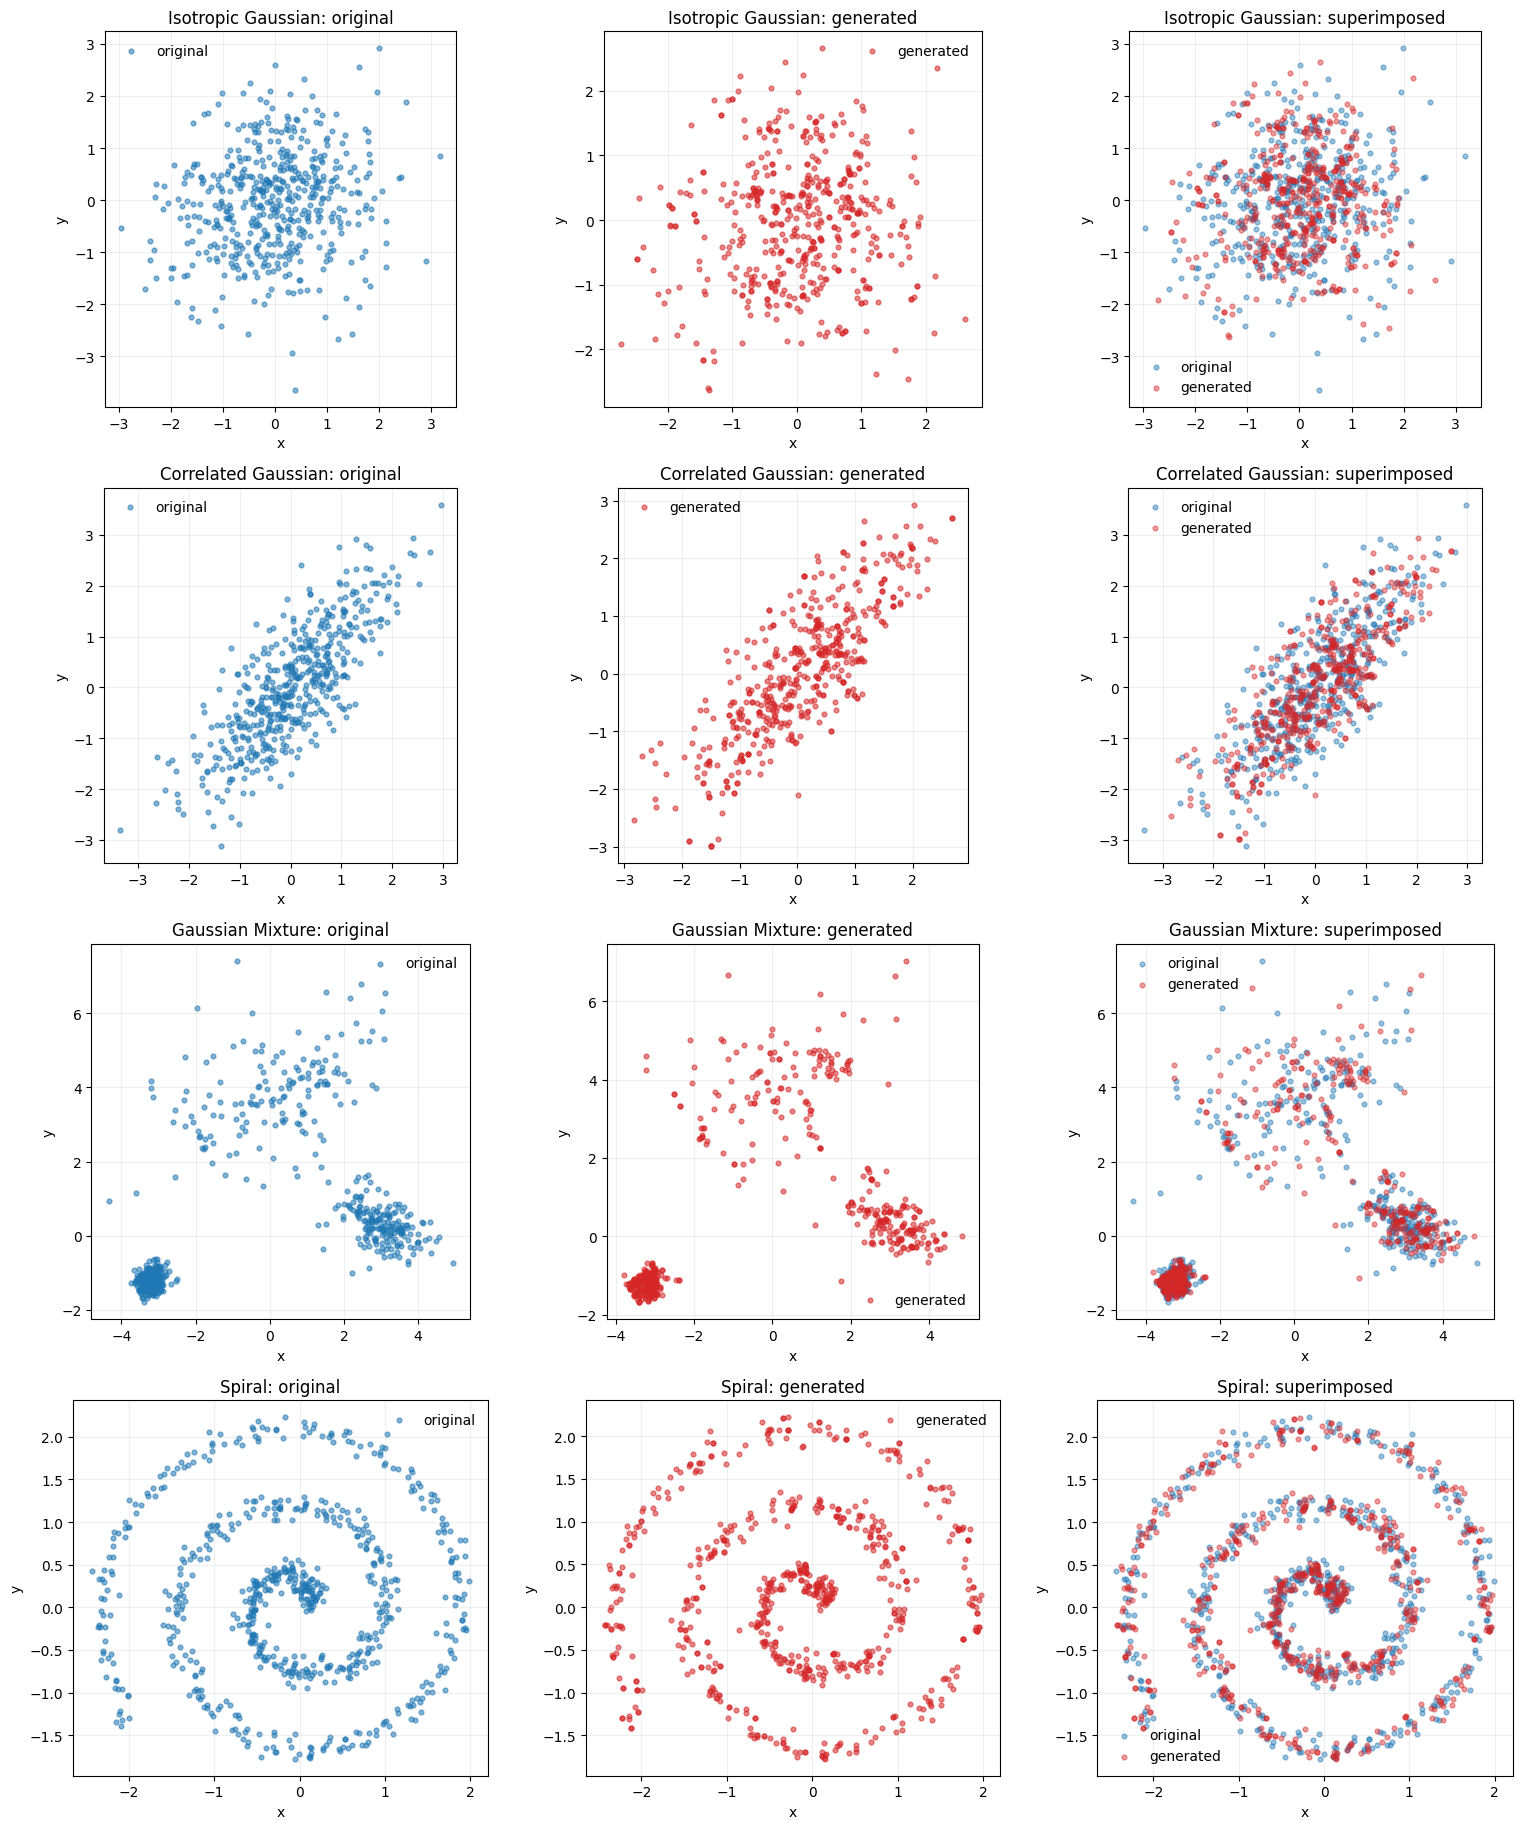

In [4]:
figure_path = ROOT / "experiments" / "figures" / "two_dimensional_distributions.pdf"
fig = plot_two_dimensional_suite(results, output_path=figure_path)
figure_path

## Individual Case Access

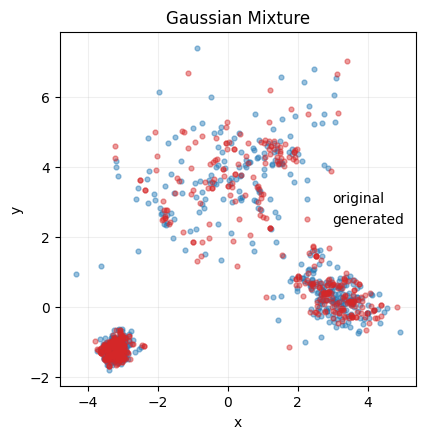

In [5]:
CASE_INDEX = -2
case = results[CASE_INDEX]["case"]
generated = results[CASE_INDEX]["generated"]
_ = plot_real_vs_generated_2d(case.dataframe, generated, title=case.title)

## Individual 1NN Distance Check

In [6]:
nearest_neighbor_distance_report(case.dataframe, generated).groupby("kind")["distance"].describe()

,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
generated_to_original_1nn,600.0,0.065929,0.088273,0.000971,0.015064,0.031015,0.084114,0.776201
original_to_original_1nn,600.0,0.099930,0.148958,0.001629,0.022499,0.047422,0.117432,1.470460


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/figures/gaussian_mixture_1nn_distance_histogram.pdf')

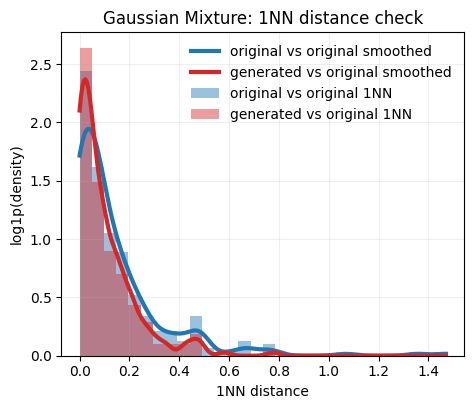

In [7]:
distance_figure_path = ROOT / "experiments" / "figures" / f"{case.key}_1nn_distance_histogram.pdf"
fig = plot_nearest_neighbor_distance_histogram(
    case.dataframe,
    generated,
    title=f"{case.title}: 1NN distance check",
    bins=30,
)
fig.savefig(distance_figure_path, bbox_inches="tight")
distance_figure_path